In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt #for visualization
from sympy import im, symbols, Eq, solve, Matrix
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

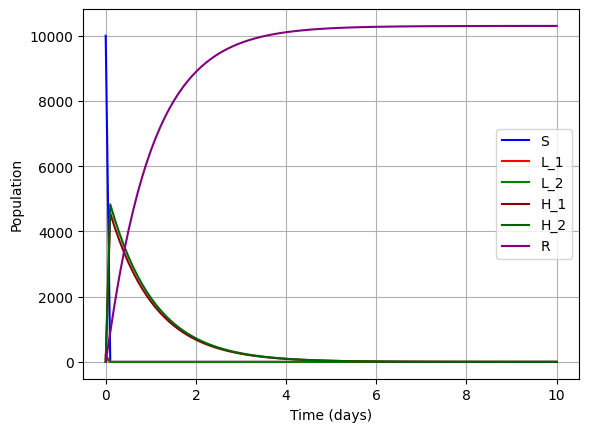

Text(0, 0.5, 'Proportion')

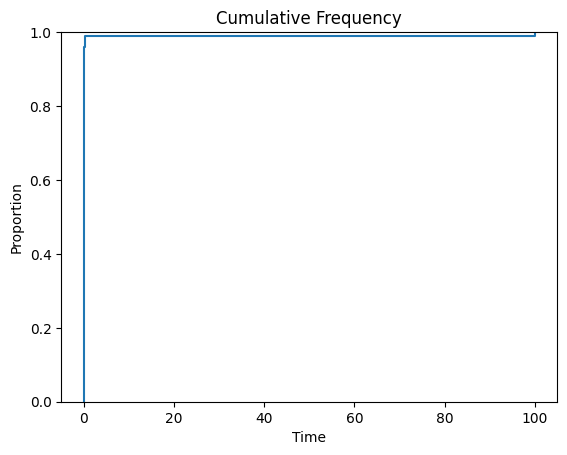

In [17]:
#set up compartmental model
Lambda = 1
mu = 0.00003333333 #1/lifespan of person
#infection rates
beta_1 = 3.374
beta_2 = 3
#eta_1 = 0
#eta_2 = 0

#progression rates
alpha_1 = 1.46
alpha_2 = 1.46
#alpha = 1

#competition: w = weight, relative competitive advantage of both strains + probability of being infected with the other

w_1 = beta_1*(alpha_1/(alpha_1 + alpha_2))
w_2 = beta_2*(alpha_2/(alpha_1 + alpha_2))

#recovery rates
gamma_1 = 1
gamma_2 = 1


# we have removed the L_12 compartment, and instead have people who move directly from L_1 or L_2 to H_1 or H_2
def model(t, state):
    S, L_1, L_2, H_1, H_2, R = state
    dSdt = Lambda - beta_1*S*H_1 - beta_2*S*H_2 - mu*S
    dL_1dt = beta_1*S*H_1 - w_2*L_1*H_2 - alpha_1*L_1 - mu*L_1
    dL_2dt = beta_2*S*H_2 - w_1*L_2*H_1 - alpha_2*L_2 - mu*L_2
    dH_1dt = alpha_1*L_1 + w_1*L_2*H_1 - gamma_1*H_1 - mu*H_1 #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
    dH_2dt = alpha_2*L_2 + w_2*L_1*H_2 - gamma_2*H_2 - mu*H_2  #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
    dRdt = gamma_1*H_1 + gamma_2*H_2 - mu*R
    return [dSdt, dL_1dt, dL_2dt, dH_1dt, dH_2dt, dRdt]

t_span = (0, 10)
initial = (10000, 200, 100, 0, 0, 0)

t_evaluate = np.linspace(0, 10, 100)

sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)


plt.plot(sol.t, sol.y[0], label='S', color='blue')
plt.plot(sol.t, sol.y[1], label='L_1', color='red')
plt.plot(sol.t, sol.y[2], label='L_2', color='green')
#plt.plot(sol.t, sol.y[3], label='L_12', color='orange')
plt.plot(sol.t, sol.y[3], label='H_1', color='darkred')
plt.plot(sol.t, sol.y[4], label='H_2', color='darkgreen')
plt.plot(sol.t, sol.y[5], label='R', color='purple')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()

data = sol.y[2]
fig, ax = plt.subplots()

# Plot the exact cumulative curve
ax.ecdf(data, label="Cumulative Incidence")

ax.set_title("Cumulative Frequency")
ax.set_xlabel("Time")
ax.set_ylabel("Proportion")

In [22]:
#calculate R0
#use the constants from the time series in above cells

S = symbols('S')
L_1 = symbols('L_1')
L_2 = symbols('L_2')
H_1 = symbols('H_1')
H_2 = symbols('H_2')
R = symbols('R')

dSdt = Lambda - beta_1*S*H_1 - beta_2*S*H_2 - mu*S
dL_1dt = beta_1*S*H_1 - w_2*L_1*H_2 - alpha_1*L_1 - mu*L_1
dL_2dt = beta_2*S*H_2 - w_1*L_2*H_1 - alpha_2*L_2 - mu*L_2
dH_1dt = alpha_1*L_1 + w_1*L_2*H_1 - gamma_1*H_1 - mu*H_1 #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
dH_2dt = alpha_2*L_2 + w_2*L_1*H_2 - gamma_2*H_2 - mu*H_2  #NOTE respective alpha added to L_12 coeff. to let c be a proportionality constant
dRdt = gamma_1*H_1 + gamma_2*H_2 - mu*R


fL1 = beta_1 * S * H_1
fL2 = beta_2 * S * H_2
#fL12 = eta_2 * L_1 * H_2 + eta_1 * L_2 * H_1
fH1 = 0 # w_1 * L_2 * H_1
fH2 = 0 #w_2 * L_1 * H_2


vL1 = w_2 * L_1 * H_2 + alpha_1 * L_1 + mu * L_1
vL2 = w_1 * L_2 * H_1 + alpha_2 * L_2 + mu * L_2
#vL12 = alpha * c_1 * L_12 + alpha * c_2 * L_12 + mu * L_12
vH1 = gamma_1 * H_1 + mu * H_1 - alpha_1 * L_1 - w_1 * L_2 * H_1
vH2 = gamma_2 * H_2 + mu * H_2 - alpha_2 * L_2 - w_2 * L_1 * H_2

f = Matrix([fL1, fL2, fH1, fH2])
v = Matrix([vL1, vL2, vH1, vH2])

variables = Matrix([L_1, L_2, H_1, H_2])
dfe = {S: Lambda/ mu, L_1: 0, L_2: 0, H_1: 0, H_2: 0}


F_dfe = f.jacobian(variables).subs(dfe)
V_dfe = v.jacobian(variables).subs(dfe)


Vinv = V_dfe.inv()

#F = F.subs(dfe)
#Vinv = Vinv.subs(dfe)

ngm = F_dfe*Vinv
#print(ngm)

eigs = np.linalg.eigvals(np.array(ngm.tolist(), dtype=float))
R0 = np.max(eigs)


print("R0:", R0)

R0: 101214.32540534787
